# Predective 

# Can we predict whether a diabetic patient's glucose will exceed 200 mg/dL in the next hour, based on their current glucose, carb intake, and basal rate?

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

 # Null Hypothesis:
H₀ — Prior glucose level, carbohydrate input, and basal rate have no significant ability to predict whether next-hour glucose will exceed 200 mg/dL.
H₁ — At least one of these features significantly predicts next-hour hyperglycemia.

In [2]:
file_path = "12_PythonPioneers_cleaned_data.xlsx"

df = pd.read_excel(file_path)
df.head()

#load dataset

,Patient ID,Date,Hour,Glucose,Heart Rate,Steps,Calories,Bolus Volume Delivered,Basal Rate,Carb Input,Bolus Category,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,HUPA0001P,2018-06-13,18,328.00,84,54,25.20,0.0,0.09,0.0,No insulin,34,Male,Other,6.3,4.5,80
1,HUPA0001P,2018-06-13,19,275.92,96,1376,139.10,0.0,0.08,0.0,No insulin,34,Male,Other,6.3,4.5,80
2,HUPA0001P,2018-06-13,20,141.75,100,1884,173.56,0.0,0.08,0.0,No insulin,34,Male,Other,6.3,4.5,80
3,HUPA0001P,2018-06-13,21,80.08,96,160,94.83,3.5,0.01,4.0,High dose,34,Male,Other,6.3,4.5,80
4,HUPA0001P,2018-06-13,22,153.42,91,213,71.89,0.0,0.03,0.0,No insulin,34,Male,Other,6.3,4.5,80


In [8]:
df = df.sort_values(by=["Patient ID", "Date", "Hour"])
#sprt data

# 1.Load and sort Load the patient data and sort it by patient, date, and hour so the time sequence is correct before we do any lag calculations.


In [ ]:
# 1. Load and sort 
file_path = "12_PythonPioneers_cleaned_data.xlsx"
df = pd.read_excel(file_path)
df = df.sort_values(["Patient ID", "Date", "Hour"]).reset_index(drop=True)



# Step 2 — Feature engineering Create three new columns:
Prior_Hour_Glucose — what was glucose 1 hour ago
Next_Hour_Glucose — what will glucose be 1 hour from now
Glucose_Spike — 1 if next hour glucose exceeds 200, 0 if not
This Glucose_Spike column becomes our target — the thing we are trying to predict.

In [ ]:
# 2. Feature engineering
df["Prior_Hour_Glucose"] = df.groupby("Patient ID")["Glucose"].shift(1)
df["Next_Hour_Glucose"]  = df.groupby("Patient ID")["Glucose"].shift(-1)
df["Glucose_Spike"]      = (df["Next_Hour_Glucose"] > 200).astype(int)
features = ["Carb Input", "Basal Rate", "Prior_Hour_Glucose"]
model_data = df[features + ["Glucose_Spike"]].dropna()


X = model_data[features]
y = model_data["Glucose_Spike"]

print("Class distribution:")
print(y.value_counts())
print(f"Spike rate: {y.mean()*100:.1f}%")

# Step 3 Scale and split Scale all features to the same range so no single feature dominates. Then split data into 80% for training the model and 20% for testing it. stratify=y ensures both splits have the same proportion of spikes.

In [ ]:

# 3. Scale + Split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Step 4 — Train the model Feed the training data into logistic regression, which learns the relationship between the three features and the spike outcome.

 # Step 5 — Evaluate performance Check how well the model predicts on unseen test data using accuracy, ROC-AUC, confusion matrix, and classification report.

In [4]:



#  4. Train model 
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]



# 5. Model performance
accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_proba)

print(f"\nModel Accuracy : {accuracy:.2f}")
print(f"ROC-AUC Score  : {roc_auc:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Class distribution:
Glucose_Spike
0    5777
1    1723
Name: count, dtype: int64
Spike rate: 23.0%

Model Accuracy : 0.82
ROC-AUC Score  : 0.81

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      1155
           1       0.72      0.39      0.50       345

    accuracy                           0.82      1500
   macro avg       0.78      0.67      0.70      1500
weighted avg       0.81      0.82      0.80      1500

Confusion Matrix:
[[1103   52]
 [ 211  134]]


# Step 6 — Null hypothesis test per feature For each feature individually, test whether it actually contributes to the prediction or if its effect could be by chance. p < 0.05 means that feature genuinely matters.

In [5]:
#6. Null hypothesis test (Wald z-test per feature)
# If p < 0.05 → reject H₀ for that feature
coefs      = model.coef_[0]
std_errors = np.sqrt(np.diag(
    np.linalg.inv(X_train.T @ X_train)
))
z_scores = coefs / std_errors
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))

hypothesis_df = pd.DataFrame({
    "Feature"  : features,
    "Coefficient": coefs.round(4),
    "Z-Score"  : z_scores.round(4),
    "P-Value"  : p_values.round(4),
    "Reject H₀": ["Yes ✓" if p < 0.05 else "No ✗" for p in p_values]
})
print("\nNull Hypothesis Test Results:")
print(hypothesis_df.to_string(index=False))

# ── 7. Overall model significance (likelihood ratio test) ─────────
null_model = LogisticRegression(random_state=42)
null_model.fit(
    np.zeros_like(X_train),
    y_train
)
log_likelihood_full = np.sum(
    y_train * np.log(model.predict_proba(X_train)[:, 1] + 1e-10) +
    (1 - y_train) * np.log(1 - model.predict_proba(X_train)[:, 1] + 1e-10)
)
log_likelihood_null = np.sum(
    y_train * np.log(y_train.mean() + 1e-10) +
    (1 - y_train) * np.log(1 - y_train.mean() + 1e-10)
)
lr_stat   = -2 * (log_likelihood_null - log_likelihood_full)
lr_pvalue = 1 - stats.chi2.cdf(lr_stat, df=len(features))

print(f"\nOverall Model Likelihood Ratio Test:")
print(f"Chi-square stat : {lr_stat:.4f}")
print(f"P-value         : {lr_pvalue:.4f}")
if lr_pvalue < 0.05:
    print("→ Reject H₀: The model as a whole is statistically significant.")
else:
    print("→ Fail to reject H₀: The model is not statistically significant.")




Null Hypothesis Test Results:
           Feature  Coefficient  Z-Score  P-Value Reject H₀
        Carb Input      -0.0089  -0.6782   0.4977      No ✗
        Basal Rate      -0.0542  -4.1959   0.0000     Yes ✓
Prior_Hour_Glucose       1.2889  99.6829   0.0000     Yes ✓

Overall Model Likelihood Ratio Test:
Chi-square stat : 1448.6885
P-value         : 0.0000
→ Reject H₀: The model as a whole is statistically significant.


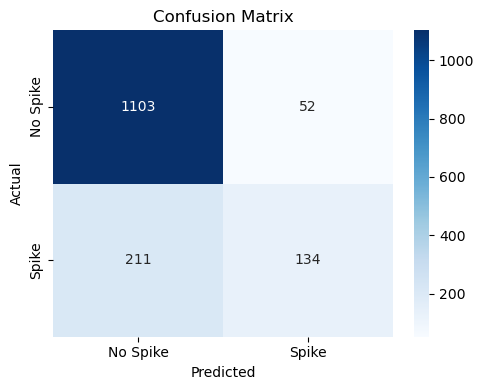

In [7]:
# 8. Visualizations 
# 8a. Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Spike', 'Spike'],
            yticklabels=['No Spike', 'Spike'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



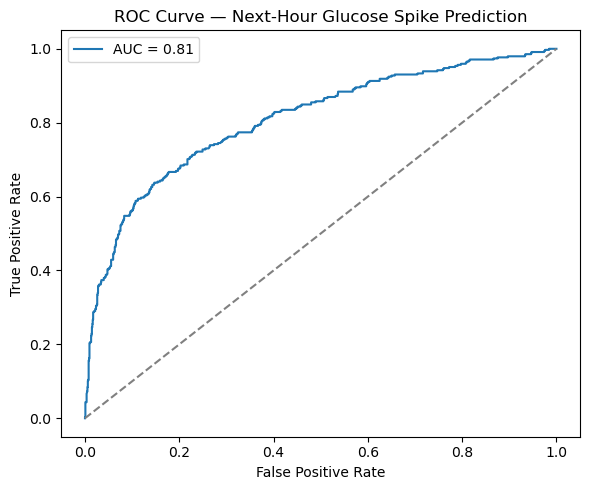

In [8]:
# 8b. ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve — Next-Hour Glucose Spike Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()





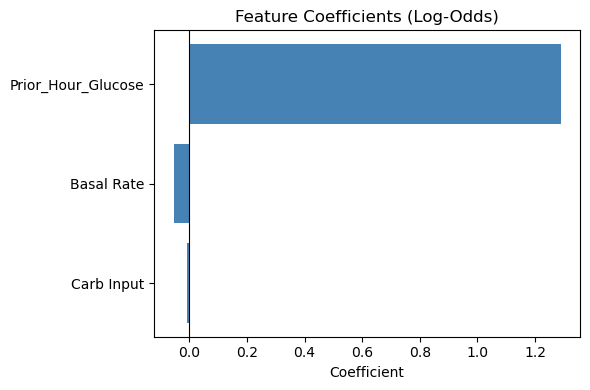

In [9]:
# 8c. Feature coefficients (importance)
plt.figure(figsize=(6, 4))
plt.barh(features, coefs, color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Feature Coefficients (Log-Odds)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()


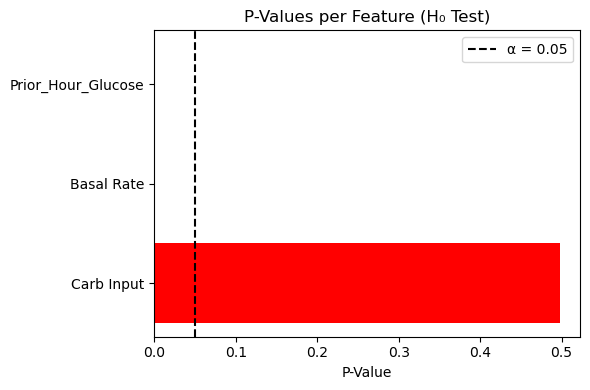

In [10]:

# 8d. P-value bar chart
colors = ['green' if p < 0.05 else 'red' for p in p_values]
plt.figure(figsize=(6, 4))
plt.barh(features, p_values, color=colors)
plt.axvline(0.05, color='black', linestyle='--', label='α = 0.05')
plt.title("P-Values per Feature (H₀ Test)")
plt.xlabel("P-Value")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# ── Summary Table ─────────────────────────────────────────────────
summary = pd.DataFrame({
    "Component": [
        "stratify=y in train-test split",
        "StandardScaler",
        "ROC-AUC Score",
        "Wald Z-Test per Feature",
        "Likelihood Ratio Test",
        "ROC Curve Plot",
        "Coefficient Plot",
        "P-Value Plot"
    ],
    "Purpose": [
        "Ensures spike class is balanced in both train and test sets",
        "Required for logistic regression to work fairly across features",
        "Better metric than accuracy alone when classes are imbalanced",
        "Tests H0 individually for each predictor — shows which features matter",
        "Tests H0 for the overall model — gives a single pass/fail verdict",
        "Visualizes model discrimination ability",
        "Shows direction and strength of each feature's effect",
        "Visually confirms which features reject H0"
    ],
    "Type": [
        "Data Splitting",
        "Preprocessing",
        "Evaluation Metric",
        "Statistical Test",
        "Statistical Test",
        "Visualization",
        "Visualization",
        "Visualization"
    ],
    "Applied To": [
        "Train / Test sets",
        "All features",
        "Full test set",
        "Each feature individually",
        "Entire model",
        "Test set predictions",
        "Model coefficients",
        "Feature p-values"
    ],
    "Threshold / Criteria": [
        "Maintains class ratio from full dataset",
        "Mean=0, Std=1 per feature",
        "AUC > 0.7 = acceptable, > 0.8 = good",
        "p < 0.05 → Reject H0 for that feature",
        "p < 0.05 → Reject H0 for overall model",
        "Closer to top-left corner = better model",
        "Positive = raises spike risk, Negative = lowers it",
        "Green bar = significant, Red bar = not significant"
    ]
})

# ── Display as formatted table ────────────────────────────────────
print("=" * 105)
print(f"{'Component':<35} {'Purpose':<45} {'Type':<20} {'Threshold':<30}")
print("=" * 105)

for _, row in summary.iterrows():
    print(f"{row['Component']:<35} {row['Purpose']:<45} {row['Type']:<20} {row['Threshold / Criteria']:<30}")
    print("-" * 105)

Component                           Purpose                                       Type                 Threshold                     
stratify=y in train-test split      Ensures spike class is balanced in both train and test sets Data Splitting       Maintains class ratio from full dataset
---------------------------------------------------------------------------------------------------------
StandardScaler                      Required for logistic regression to work fairly across features Preprocessing        Mean=0, Std=1 per feature     
---------------------------------------------------------------------------------------------------------
ROC-AUC Score                       Better metric than accuracy alone when classes are imbalanced Evaluation Metric    AUC > 0.7 = acceptable, > 0.8 = good
---------------------------------------------------------------------------------------------------------
Wald Z-Test per Feature             Tests H0 individually for each predictor — show

In [12]:
summary.to_excel("model_summary_table.xlsx", index=False)
print("Table saved to model_summary_table.xlsx")

Table saved to model_summary_table.xlsx
